In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pybaselines import Baseline, utils
from scipy.optimize import curve_fit
from sklearn.metrics import auc
from scipy.stats import linregress
from scipy.signal import  peak_widths
import scipy.integrate as integrate
from matplotlib import colormaps
from colorspacious import cspace_converter


In [39]:
path = "/Users/verityjanerothermelsmith/Downloads/CuGeGaS4/"
files = [file for file in os.listdir(path) if  file.endswith('.txt')]
dfs=[]
for file in sorted(files): 
    df = pd.read_csv(file, sep='\t', names=["eV", "intensity"])
    #print(file)
    #display(df)
    dfs.append(df[(df["eV"] >= 1.2) & (df["eV"] <= 2.1)])
power_list= [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.,  1.1, 1.2, 1.3, 1.4]

#print(dfs)


In [48]:


power_legend= [str(s)+" mW" for s in power_list]
rev = power_legend[::-1]
print(power_list)
print(rev)

[1.4, 1.3, 1.2, 1.1, 1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]
['0.1 mW', '0.2 mW', '0.3 mW', '0.4 mW', '0.5 mW', '0.6 mW', '0.7 mW', '0.8 mW', '0.9 mW', '1.0 mW', '1.1 mW', '1.2 mW', '1.3 mW', '1.4 mW']


In [41]:
for index, df in enumerate(dfs):
    x= df["eV"]
    y= df["intensity"]
    baseline_fitter = Baseline(x_data=x)
    bkg_1, params_1 = baseline_fitter.modpoly(y, poly_order=1)
    df["intensity-bkg"] = y - bkg_1

In [42]:
display(df)

,eV,intensity,intensity-bkg
210,2.09979,2080.0,-113.639471
211,2.09856,2068.0,-125.420571
212,2.09733,2051.0,-142.201672
213,2.09610,2106.0,-86.982772
214,2.09487,2125.0,-67.763872
...,...,...,...
1497,1.20161,1911.0,-122.792744
1498,1.20121,1926.0,-107.721557
1499,1.20081,1885.0,-148.650371
1500,1.20042,1894.0,-139.580963


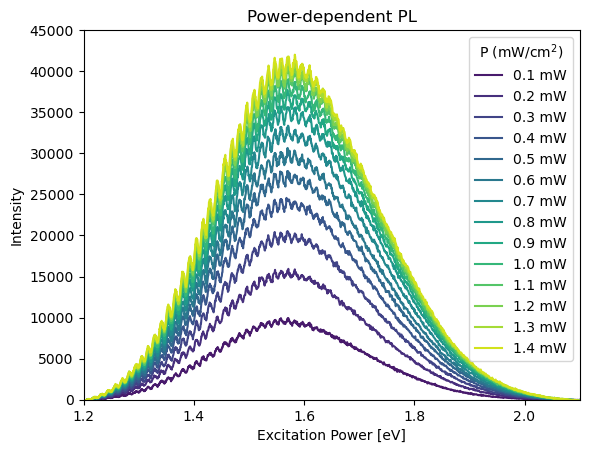

<Figure size 640x480 with 0 Axes>

In [53]:
#colour_map = plot_color_gradients('Perceptually Uniform Sequential', ["viridis"])
                                  
for index, df in enumerate(dfs):
    x= df["eV"]
    y= df["intensity"]
    y_corrected= df["intensity-bkg"]
    #plt.plot(x, y, label='raw data', lw=1.5)
    #plt.plot(x, bkg_1, '--', label='modpoly')
    with sns.color_palette("viridis", n_colors=14):

        plt.plot(x, y_corrected, '-',  label=rev[index])

    #plt.text(1.25, 35000, "CuGaSnS4", fontsize=10)
    #plt.text(1.25, 32000, "532 nm ", fontsize=10)

    #plt.show()
title="Power-dependent PL"
plt.title(title)
plt.legend(title="P (mW/cm$^2$)")
plt.ylabel("Intensity")
plt.xlabel("Excitation Power [eV]")
plt.ylim(0, 45000)
plt.xlim(1.2, 2.1)

plt.show()
plt.savefig("power_dependance.jpg")

### new approach

210       5.410957
211       5.603336
212       5.802079
213       6.007380
214       6.219435
           ...    
1497    218.440998
1498    216.681991
1499    214.935287
1500    213.244028
1501    211.521418
Name: eV, Length: 1292, dtype: float64
210    -44.607597
211    -22.666622
212    -37.725647
213    -19.784672
214    -37.843697
          ...    
1497   -55.709325
1498   -60.728520
1499   -67.747715
1500   -59.766430
1501   -51.785625
Name: intensity-bkg, Length: 1292, dtype: float64
210      11.134417
211      11.520176
212      11.918341
213      12.329275
214      12.753352
           ...    
1497    348.360151
1498    345.575187
1499    342.809569
1500    340.131616
1501    337.403892
Name: eV, Length: 1292, dtype: float64
210     -45.724772
211     -38.777506
212     -33.830241
213     -22.882975
214     -30.935709
           ...    
1497    -62.232846
1498   -101.249995
1499    -64.267145
1500    -72.283865
1501    -69.301015
Name: intensity-bkg, Length: 1292, dtype: float

,excitation power,peak position,peak position error,area,area error,FWHM,FWHM error,R $^2$
0,0.1 mW,1.574668,0.000263,3212.626482,7.608432e-11,0.320023,0.000083,0.999999
1,0.2 mW,1.578635,0.000262,5234.511381,1.097497e-10,0.322890,0.000083,0.999999
2,0.3 mW,1.580806,0.000258,6848.507299,1.303855e-10,0.324778,0.000083,0.999999
3,0.4 mW,1.581525,0.000256,8250.866602,1.481550e-10,0.325886,0.000082,0.999999
4,0.5 mW,1.582464,0.000263,9399.435609,1.568253e-10,0.327277,0.000085,0.999999
5,0.6 mW,1.582726,0.000263,10307.254252,1.643294e-10,0.328175,0.000085,0.999999
6,0.7 mW,1.584100,0.000263,11327.730670,1.681254e-10,0.329499,0.000085,0.999999
7,0.8 mW,1.585182,0.000265,12232.179029,1.698714e-10,0.330763,0.000086,0.999999
8,0.9 mW,1.585593,0.000268,12851.243679,1.709901e-10,0.331647,0.000088,0.999999
9,1.0 mW,1.585623,0.000271,13376.787012,1.728058e-10,0.332328,0.000089,0.999999


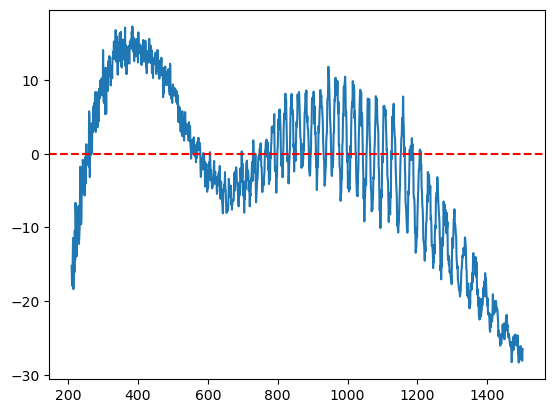

In [ ]:
#x, y inputs can be lists or 1D numpy arrays

def gauss(x, mu, sigma, A):
    return A*np.exp(-(x-mu)**2/2/sigma**2)


def fit(x, y, power):
    params, cov = curve_fit(gauss, x, y, (1.6, .2, 10000)) 

    # residuals 
    x_fit = np.linspace(x.min(), x.max(), 500)
    y_pred= gauss(x, *params)
    print(y_pred)
    print(y)
    residuals = (y- y_pred)/np.sqrt(y_pred)

    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y-np.mean(y))**2)
    r_squared = 1 - (ss_res / ss_tot)

    sigma=np.sqrt(np.diag(cov))
    
    #plot combined...
    #plt.plot(x_fit, bimodal(x_fit, *params), color='red', lw=3, label='model')
    #...and individual Gauss curves
    peak_1= gauss(x_fit, *params[:3])
    #plt.plot(x_fit, peak_1, color='red', lw=1, ls="--", label='Gaussian fit')
    #plt.show() 

    mu=params[0]
    sigma1=params[1]
    A= params[2]
    #alternative area under the curve
    def make_gauss(x):
        return A*np.exp(-(x-mu)**2/2/sigma1**2) 
    mu=params[0]

    A= params[2]
    result, error = integrate.quad(make_gauss, 1.2, 2.1)

    #and the original data points if no histogram has been created before
    #plt.plot(x, y, color="black", lw=1,ls="--",  label="baseline-corrected data")
    # plt.legend()
    # plt.title(f"{power} mW")

    
    params_df_1= pd.DataFrame(data={'params': params, 'sigma': sigma}, index=gauss.__code__.co_varnames[1:])


    # peak pos +- 2.355/2 * sigma
    fwhm_1_1 = params[0] - (2.355/2) * params[1]
    fwhm_1_2 = params[0] + (2.355/2) * params[1]
    fwhm= 2.355 * params[1]
    fwhm_error = fwhm*sigma[1]

    #final metrics
    peak_pos = params[0]
    peak_err = sigma[0]
    #plt.show() 

    return peak_pos, peak_err, result, error, fwhm, fwhm_error, residuals, r_squared

expected_list=[(1.6, .2, 20000, 1.8, .2, 40000),(1.6, .2, 20000, 1.8, .2, 40000),(1.6, .2, 20000, 1.8, .2, 40000), 
               (1.6, .2, 20000, 1.8, .2, 40000), (1.6, .2, 15000, 1.8, .2, 35000),(1.6, .2, 15000, 1.8, .2, 35000),
               (1.6, .2, 15000, 1.8, .2, 35000), (1.6, .2, 15000, 1.8, .2, 35000), (1.6, .2, 15000, 1.8, .2, 35000),
               (1.6, .2, 15000, 1.8, .2, 35000),(1.6, .2, 15000, 1.8, .2, 35000), (1.6, .2, 20000, 1.8, .2, 35000),
               (1.6, .2, 20000, 1.8, .2, 35000)]


peak_pos_list= []
peak_err_list= []
area_list=[]
area_error_list=[]
fwhm_list=[]
fwhm_error_list=[]
residuals_list=[]
r2_list=[]

for index, df in enumerate(dfs):
    y = df["intensity-bkg"]
    x= df["eV"]
    power= power_list[index]
    

    peak_pos, peak_err, result, error, fwhm, fwhm_error, residuals, r_squared  = fit(x, y, power) 

    peak_pos_list.append(peak_pos)
    peak_err_list.append(peak_err)
    area_list.append(result)
    area_error_list.append(error)
    fwhm_list.append(fwhm)
    fwhm_error_list.append(fwhm_error)
    residuals_list.append(residuals)
    r2_list.append(r_squared)

# print(peak_pos_list)
# print(peak_err_list)
# print(area_list)
# print(area_error_list)
# print(fwhm_list)
# print(fwhm_error_list)
metrics = pd.DataFrame({"excitation power": power_legend, 'peak position': peak_pos_list,'peak position error': peak_err_list, 
                        'area': area_list,'area error': area_error_list,
                        'FWHM': fwhm_list,'FWHM error': fwhm_error_list,
                        'R $^2$': r_squared})
display(metrics)

plt.plot(residuals_list[3])
plt.axhline(y=0, color='r', linestyle='--')
plt.show()

[-1.         -0.69897    -0.52287875 -0.39794001 -0.30103    -0.22184875
 -0.15490196 -0.09691001 -0.04575749  0.          0.04139269  0.07918125
  0.11394335  0.14612804]


TypeError: can't multiply sequence by non-int of type 'numpy.float64'

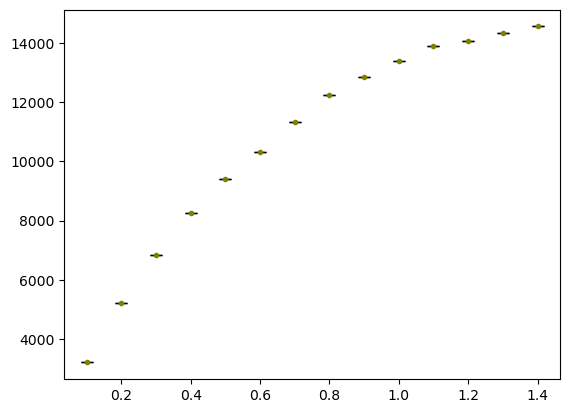

In [ ]:
# Log-log plot with error bars
x=power_list
y=area_list
y_error= area_error_list
plt.errorbar(x, y, yerr=y_error, fmt='o', color="olive", ecolor="black", capsize=4, ms=3,label="Data with error")

log_x = np.log10(power_list)
print(log_x)
log_y= np.log10(area_list)
res = linregress(log_x, log_y) 
y_pred= (10**(res.slope) * x + 10**(res.intercept))

k = res.slope.round(3)
k_err= res.stderr.round(3)
r2=res.rvalue
plt.plot(log_x, y_pred, color='purple', lw=1, ls="--", label=f'k = {k} +- {k_err}')

plt.xscale("log")
plt.yscale("log")
plt.xlabel("X-axis (log scale)")
plt.ylabel("Y-axis (log scale)")
plt.title("Log-Log Plot with Error Bars in Python")
plt.legend()
plt.show()

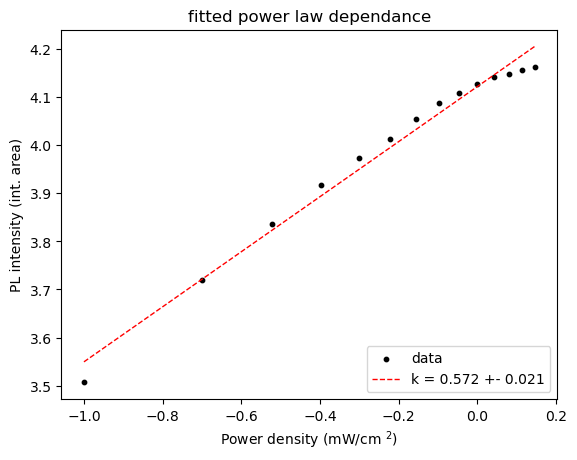

LinregressResult(slope=np.float64(0.5720962741598314), intercept=np.float64(4.121499085685162), rvalue=np.float64(0.9921813442486825), pvalue=np.float64(3.243374294732722e-12), stderr=np.float64(0.02077389441281897), intercept_stderr=np.float64(0.008118073223227242))


<Figure size 640x480 with 0 Axes>

In [ ]:
log_x = np.log10(power_list)
log_y= np.log10(area_list)
log_y_err=np.log10(area_error_list)

res = linregress(log_x, log_y) 
y_pred= res.slope * log_x + res.intercept

k = res.slope.round(3)
k_err= res.stderr.round(3)
r2=res.rvalue


plt.scatter(log_x, log_y, marker='o', color='black', s=10, label='data')

#plt.errorbar(log_x, log_y, yerr=log_y_err, fmt='o', color="olive", ecolor="black", capsize=4, ms=3,label="Data with error")


plt.plot(log_x, y_pred, color='red', lw=1, ls="--", label=f'k = {k} +- {k_err}')

plt.legend(loc='lower right')
plt.xlabel("Power density (mW/cm $^2$)")
plt.ylabel("PL intensity (int. area)")
# plt.text(-.8, 4, 'k = 0.572 +- 0.021', fontsize=10)
# plt.text(-.8, 3.95, 'r$^2$ = 0.992', fontsize=10)
# plt.xscale('log')
# plt.yscale('log')
plt.title("fitted power law dependance")
plt.show()
plt.savefig("k_val.jpg")
print(res)

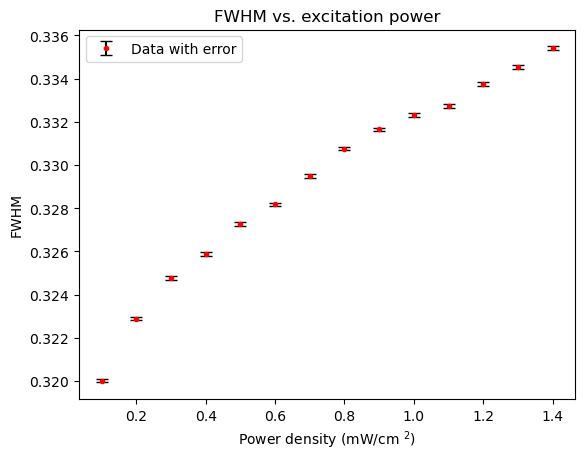

<Figure size 640x480 with 0 Axes>

In [ ]:
# Log-log plot with error bars
x=power_list
y=fwhm_list
y_error= fwhm_error_list
plt.errorbar(x, y, yerr=y_error, fmt='o', color="red", ecolor="black", capsize=4, ms=3,label="Data with error")


plt.xlabel("Power density (mW/cm $^2$)")
plt.ylabel("FWHM")
plt.title("FWHM vs. excitation power")
plt.legend()
plt.show()
plt.savefig("fwhm.jpg")

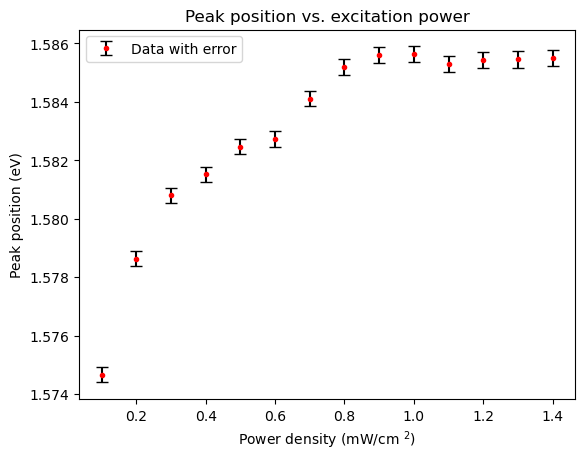

In [ ]:
# Log-log plot with error bars
x=power_list
y=peak_pos_list
y_error= peak_err_list
plt.errorbar(x, y, yerr=y_error, fmt='o', color="red", ecolor="black", capsize=4, ms=3,label="Data with error")


plt.xlabel("Power density (mW/cm $^2$)")
plt.ylabel("Peak position (eV)")
plt.title("Peak position vs. excitation power")
plt.legend()
plt.savefig("peak_pos.jpg")
plt.show()